In [24]:
import evaluation_functions
import importlib

importlib.reload(evaluation_functions)

<module 'evaluation_functions' from '/Users/paigepark/Desktop/repos/deep-fert/code/evaluation/evaluation_functions.py'>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [32]:
forecasts = []
for i in range(1,6):
    forecast = (
        np.loadtxt(f'../../data/dl_forecast_{i}.txt')
    )
    forecasts.append(forecast)

In [33]:
forecasts

[array([[   0.        , 2006.        ,   13.        ,   -9.97201538],
        [   0.        , 2006.        ,   14.        ,   -8.30747223],
        [   0.        , 2006.        ,   15.        ,   -6.68474197],
        ...,
        [  38.        , 2015.        ,   52.        ,  -11.12908936],
        [  38.        , 2015.        ,   53.        ,  -11.30507565],
        [  38.        , 2015.        ,   54.        ,  -11.31706905]],
       shape=(16254, 4)),
 array([[   0.        , 2006.        ,   13.        ,   -9.99043465],
        [   0.        , 2006.        ,   14.        ,   -8.08623695],
        [   0.        , 2006.        ,   15.        ,   -6.53384495],
        ...,
        [  38.        , 2015.        ,   52.        ,  -10.6046629 ],
        [  38.        , 2015.        ,   53.        ,  -11.1662035 ],
        [  38.        , 2015.        ,   54.        ,  -11.31045341]],
       shape=(16254, 4)),
 array([[   0.        , 2006.        ,   13.        ,  -10.19431305],
        [ 

In [34]:
actual = np.loadtxt('../../data/asfr_test.txt')

In [35]:
forecasts_exp = [f.copy() for f in forecasts]
for f in forecasts_exp:
    f[:, 3] = np.exp(f[:, 3])

In [36]:
mse_dl = []
for i in range(0,4):
    mse_dl.append(evaluation_functions.calculate_error(forecasts_exp[i], actual, changeratetolog=True))

In [37]:
mse_dl_ave = np.mean(mse_dl)

In [ ]:
forecasts_relu = np.loadtxt(f"../data/dl_forecast_explore.txt")
forecasts_relu[:, 3] = np.exp(forecasts_relu[:, 3])

In [ ]:
mse_explore = evaluation_functions.calculate_error(forecasts_relu, actual, changeratetolog=True)

In [ ]:
forecasts_nonlog = np.loadtxt(f"../data/dl_forecast_nonlog.txt")
mse_nl = evaluation_functions.calculate_error(forecasts_nonlog, actual, changeratetolog=True)

In [ ]:
forecasts_nonlog

array([[0.00000000e+00, 2.00600000e+03, 1.30000000e+01, 7.59442395e-04],
       [0.00000000e+00, 2.00600000e+03, 1.40000000e+01, 8.67713883e-04],
       [0.00000000e+00, 2.00600000e+03, 1.50000000e+01, 2.60379654e-03],
       ...,
       [3.80000000e+01, 2.01500000e+03, 5.20000000e+01, 8.13824357e-04],
       [3.80000000e+01, 2.01500000e+03, 5.30000000e+01, 7.86700111e-04],
       [3.80000000e+01, 2.01500000e+03, 5.40000000e+01, 7.70458719e-04]],
      shape=(16254, 4))

In [ ]:
mse_nl

(np.float64(2.6032841550744403),
 np.float64(1.6134696015340482),
 np.float64(-0.30882874261519266))

In [38]:
forecasts_lc = np.loadtxt('../../data/lc_forecast.csv', delimiter=',')

In [39]:
mse_lc = evaluation_functions.calculate_error(forecasts_lc, actual, changeratetolog=True)

In [40]:
mse_lc

np.float64(0.5571171974697885)

In [41]:
forecasts_hu = np.loadtxt('../../data/hu_forecast.csv', delimiter=',')

In [42]:
mse_hu = evaluation_functions.calculate_error(forecasts_hu, actual, changeratetolog=True)

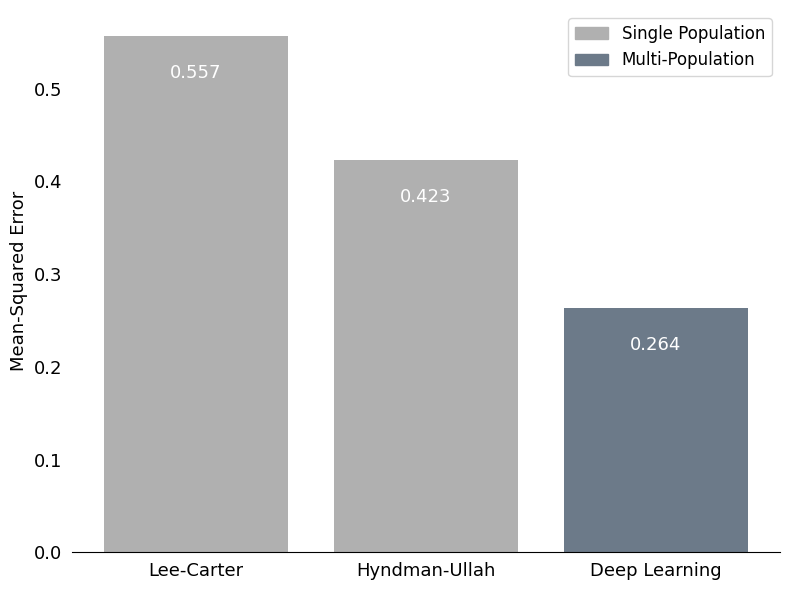

In [48]:
import matplotlib.pyplot as plt
from matplotlib import patches

values = [mse_lc, mse_hu, mse_dl_ave]  # Assuming mse_dl_ave is the relevant DL result to compare
labels = ['Lee-Carter', 'Hyndman-Ullah', 'Deep Learning'] 

# Define bar colors: light gray for classic methods, darker gray-blue for DL
bar_colors = ['#B0B0B0', '#B0B0B0', '#6C7A89']

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(labels, values, color=bar_colors)

# Clean axes (matching reference style)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False, bottom=False, labelsize=13)

# Bar labels (values on bars)
for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval - 0.03,
        f'{yval:.3f}',
        ha='center',
        va='top',
        fontsize=13,
        color='white' if yval > 0.15 else 'black'
    )

# Legend with neutral tones
legend_handles = [
    patches.Patch(color='#B0B0B0', label='Single Population'),
    patches.Patch(color='#6C7A89', label='Multi-Population')
]
ax.legend(handles=legend_handles, fontsize=12, loc='upper right')

# Labels
ax.set_ylabel('Mean-Squared Error', fontsize=13)
ax.set_xlabel('')

plt.tight_layout()
plt.savefig("../../data/figures/prelim_results.pdf", format="pdf", bbox_inches='tight', transparent=True)
plt.show()

In [51]:
# Heterogeneity of performance across country (feature 0) and age (feature 2)
# DL results are averaged across the 5 forecast runs.

def avg_mse_by_category(forecasts_list, actual, feature_index):
    dicts = [
        evaluation_functions.calculate_error_by_category(f, actual, feature_index, changeratetolog=True)
        for f in forecasts_list
    ]
    keys = sorted(set().union(*[d.keys() for d in dicts]))
    return {k: np.mean([d[k] for d in dicts if k in d]) for k in keys}

def mse_by_category(forecast, actual, feature_index):
    d = evaluation_functions.calculate_error_by_category(forecast, actual, feature_index, changeratetolog=True)
    return {k: d[k] for k in sorted(d.keys())}

# By age (feature_index=2)
age_lc = mse_by_category(forecasts_lc, actual, 2)
age_hu = mse_by_category(forecasts_hu, actual, 2)
age_dl = avg_mse_by_category(forecasts_exp, actual, 2)

# By country (feature_index=0)
geo_lc = mse_by_category(forecasts_lc, actual, 0)
geo_hu = mse_by_category(forecasts_hu, actual, 0)
geo_dl = avg_mse_by_category(forecasts_exp, actual, 0)

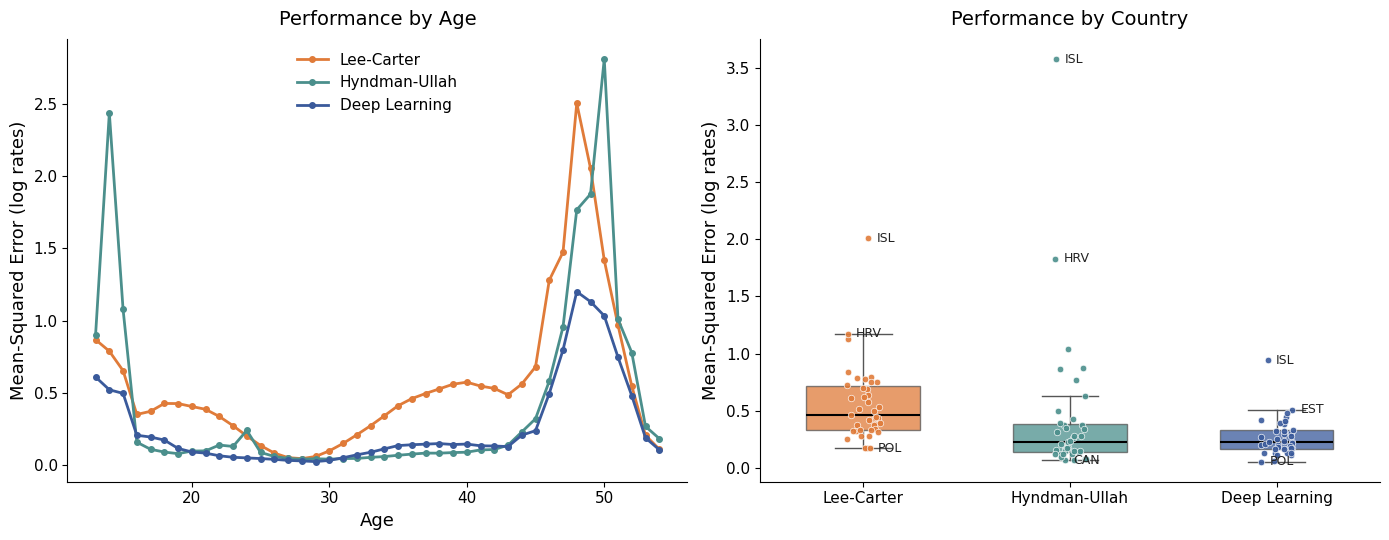

In [56]:
from matplotlib import patches

geos_key = np.load('../../data/geos_key.npy', allow_pickle=True)
geo_names = {int(idx): name for name, idx in geos_key}

method_colors = {
    'Lee-Carter': '#E07B39',      # warm orange
    'Hyndman-Ullah': '#4B8F8C',   # teal
    'Deep Learning': '#3A5A9B',   # deep blue
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ---- Panel 1: MSE by age ----
ax = axes[0]
for name, d in [('Lee-Carter', age_lc), ('Hyndman-Ullah', age_hu), ('Deep Learning', age_dl)]:
    xs = sorted(d.keys())
    ys = [d[k] for k in xs]
    ax.plot(xs, ys, marker='o', markersize=4, linewidth=2,
            color=method_colors[name], label=name)

ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Mean-Squared Error (log rates)', fontsize=13)
ax.set_title('Performance by Age', fontsize=14, pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=11)
ax.legend(fontsize=11, frameon=False, loc='upper center')

# ---- Panel 2: distribution of MSE across countries ----
ax = axes[1]
geo_dicts = [geo_lc, geo_hu, geo_dl]
labels = ['Lee-Carter', 'Hyndman-Ullah', 'Deep Learning']
positions = np.arange(len(labels))

geo_data = [list(d.values()) for d in geo_dicts]

bp = ax.boxplot(
    geo_data, positions=positions, widths=0.55, patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='#555555'),
    capprops=dict(color='#555555'),
)
for patch, name in zip(bp['boxes'], labels):
    patch.set_facecolor(method_colors[name])
    patch.set_edgecolor('#555555')
    patch.set_alpha(0.75)

rng = np.random.default_rng(0)
for i, (d, name) in enumerate(zip(geo_dicts, labels)):
    keys = list(d.keys())
    vals = np.array([d[k] for k in keys])
    jitter = rng.uniform(-0.08, 0.08, size=len(vals))
    xs = np.full(len(vals), i) + jitter
    ax.scatter(xs, vals, color=method_colors[name], edgecolor='white',
               linewidth=0.5, s=22, alpha=0.9, zorder=3)

    # label the 2 highest-MSE and 1 lowest-MSE countries per method
    order = np.argsort(vals)
    to_label = list(order[-2:]) + [order[0]]
    for j in to_label:
        label = geo_names.get(int(keys[j]), str(keys[j]))
        ax.annotate(
            label,
            xy=(xs[j], vals[j]),
            xytext=(6, 0), textcoords='offset points',
            fontsize=9, color='#222222', va='center',
        )

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Mean-Squared Error (log rates)', fontsize=13)
ax.set_title('Performance by Country', fontsize=14, pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig("../../data/figures/heterogeneity_by_age_country.pdf",
            format="pdf", bbox_inches='tight', transparent=True)
plt.show()